In [17]:
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Read the list of filenames from the configuration file
with open('../file_list.txt', 'r', encoding='utf-8') as config_file:
    file_names = config_file.read().splitlines()

# Regex pattern to match the data format
pattern = r'\[(.*?)\] (.*?): (.*)'

# Initialize an empty list to store parsed data
datalist = []
stream_count = 0
# Iterate over each specified file
for file in file_names:
    full_path = f"../data/{file}"
    with open(full_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(pattern, line)
            if match:
                date, user, message = match.groups()
                datalist.append([date, user, message,stream_count])
    stream_count = stream_count + 1

# Create a DataFrame from the parsed data
data = pd.DataFrame(datalist, columns=["date", "user", "message","stream"])
data['date'] = pd.to_datetime(data['date'])

In [24]:
data_t = data[data['user'] == 'balintboss']


data_t.describe()


,stream
count,106458.000000
mean,405.341675
std,177.533312
min,0.000000
25%,268.000000
50%,418.000000
75%,561.000000
max,699.000000


In [25]:
# Assuming 'data' is your DataFrame
text = " ".join(data_t["message"])

In [26]:
wordcloud = WordCloud(width=2000, height=1000, background_color='black').generate(text)


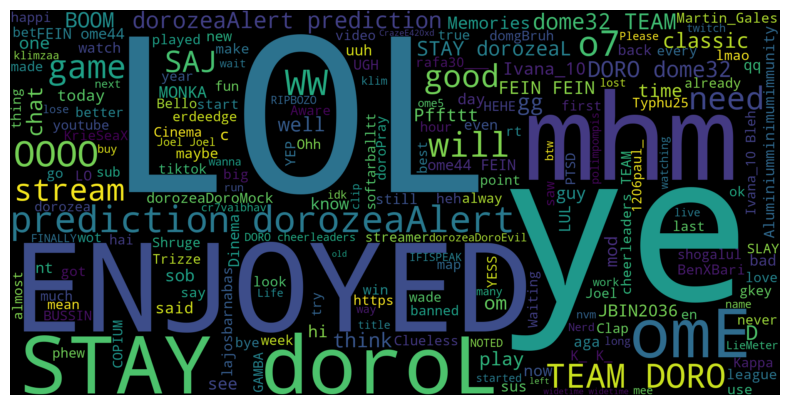

In [27]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
